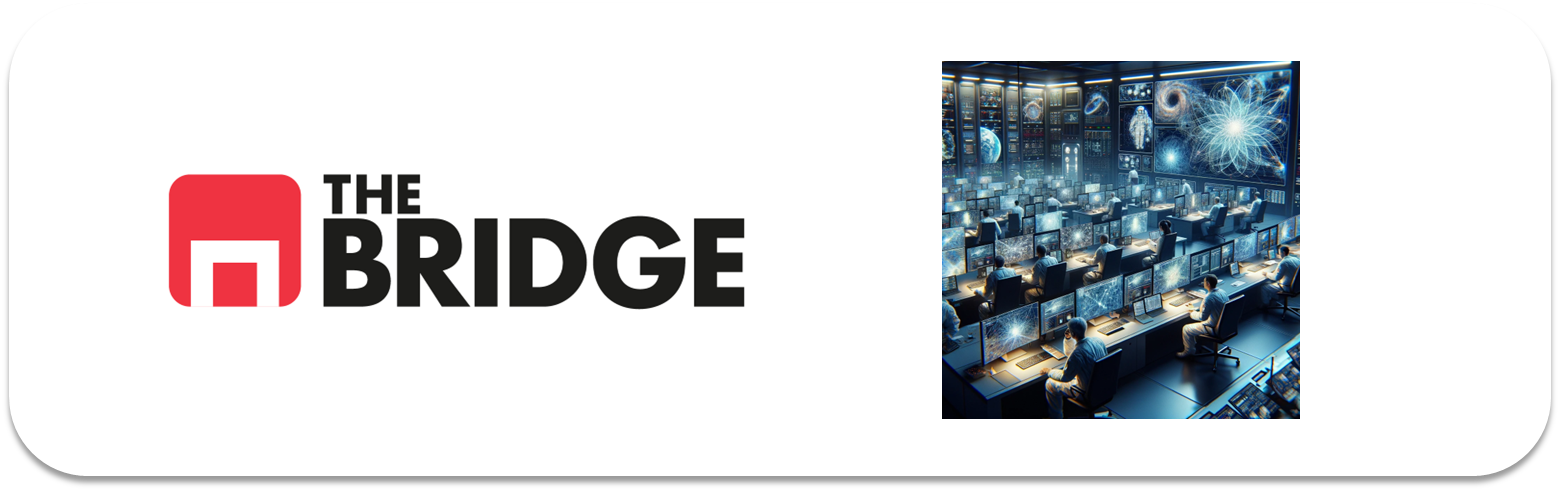

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [5]:
import cv2
import keras
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import gc

from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from time import time

pd.options.mode.copy_on_write = True

C:\Users\User\AppData\Local\Temp\ipykernel_10704\4210532528.py:14: Pandas4Warning: The 'mode.copy_on_write' option is deprecated. Copy-on-Write can no longer be disabled (it is always enabled with pandas >= 3.0), and setting the option has no impact. This option will be removed in pandas 4.0.
  pd.options.mode.copy_on_write = True


In [6]:
import tensorflow as tf
print("GPUs disponibles:", len(tf.config.list_physical_devices('GPU')))

GPUs disponibles: 0


### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



### **1. Preparación de datos**

Nota: el enunciado de esta práctica menciona "el ejercicio de clasificación de paisajes de la unidad anterior", pero esa práctica no existe. La práctica obligatoria anterior real es la de clasificación de perros y gatos (CAPTCHA), así que usamos ese dataset y esa CNN como base de comparación para el transfer learning y fine-tuning.

1.1. Carga de datos

In [7]:
TAM = 75  # antes 32, ahora 75 (mínimo que admite InceptionV3)

def cargar_imagenes(lista_directorios):
    X = []
    y = []
    nombres = []

    for directorio in lista_directorios:
        for fichero in sorted(os.listdir(directorio)):
            ruta_imagen = directorio + "/" + fichero

            imagen = cv2.imread(ruta_imagen)
            imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
            imagen = cv2.resize(imagen, (TAM, TAM))
            X.append(imagen)

            clase = fichero.split(".")[0]
            if clase == "cat":
                y.append(0)
            else:
                y.append(1)

            nombres.append(ruta_imagen)

    return np.array(X), np.array(y), nombres

In [9]:
directorios_train = ["./data/github_train_0",
                     "./data/github_train_1",
                     "./data/github_train_2",
                     "./data/github_train_3"]

X_train, y_train, nombres_train = cargar_imagenes(directorios_train)
X_test, y_test, nombres_test = cargar_imagenes(["./data/github_test"])

print("Train:", X_train.shape, y_train.shape)
print("Test:", X_test.shape, y_test.shape)
print("Rango de valores:", X_train.min(), "-", X_train.max())
print("Gatos y perros en train:", np.bincount(y_train))

Train: (4000, 75, 75, 3) (4000,)
Test: (1000, 75, 75, 3) (1000,)
Rango de valores: 0 - 255
Gatos y perros en train: [2000 2000]


1.3. Shuffle para barajar

In [12]:
X_train, y_train, nombres_train = shuffle(X_train, y_train, nombres_train, random_state=42)
print("Primeras 20 etiquetas:", y_train[:20])

Primeras 20 etiquetas: [1 1 0 1 0 0 1 1 1 0 0 0 1 1 1 0 1 1 1 1]


1.4. Escalado

In [15]:
X_train = (X_train / 127.5) - 1.0
X_test = (X_test / 127.5) - 1.0

print("Rango tras escalar:", X_train.min(), "-", X_train.max())

Rango tras escalar: -1.0 - 1.0


InceptionV3 espera rango -1 a 1

1.5. Visualización (con función reutilizable)

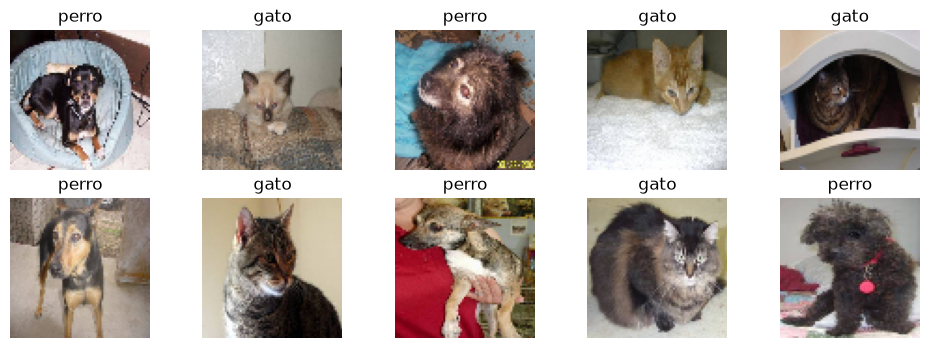

In [16]:
def mostrar_imagenes(X, y, n=10):
    plt.figure(figsize=(12, 4))
    indices = np.random.randint(0, len(X), n)
    for pos, i in enumerate(indices):
        plt.subplot(2, n // 2, pos + 1)
        # Deshacemos el escalado -1,1 -> 0,1 solo para visualizar bien
        plt.imshow((X[i] + 1) / 2)
        plt.title("perro" if y[i] == 1 else "gato")
        plt.axis("off")
    plt.show()

mostrar_imagenes(X_train, y_train)

### **2. InceptionV3**

In [17]:
from keras.applications import InceptionV3

### **3. Transfer Learning**

3.1. Carga del moodelo

In [18]:
# Cargamos el modelo preentrenado sin su cabeza densa
base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(TAM, TAM, 3))

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


3.2. Congelamos las capas

In [20]:
# Congelamos sus capas: no queremos tocar lo que ya aprendió con ImageNet
for layer in base_model.layers:
    layer.trainable = False

def prepare_model(base_model=base_model):
    x = keras.layers.Flatten()(base_model.output)

    # Una única capa densa oculta
    x = keras.layers.Dense(512, activation='relu')(x)
    x = keras.layers.Dropout(rate=0.5)(x)

    # Salida binaria (gato/perro) con sigmoid
    x = keras.layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(base_model.input, x)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = prepare_model()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 75, 75, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 37, 37,    │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 37, 37,    │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 37, 37,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 35, 35,    │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 35, 35,    │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 35, 35,    │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 35, 35,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 17, 17,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 17, 17,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 17, 17,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 17, 17,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 15, 15,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 15, 15,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 15, 15,    │          0 │ batch_normalizat

 Total params: 22,852,385 (87.17 MB)

 Trainable params: 1,049,601 (4.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

#### **Earlystopping**

In [21]:
early_stopping = keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

t_zero = time()
history = model.fit(X_train, y_train,
                    batch_size=32,
                    validation_split=0.2,
                    epochs=30,
                    callbacks=[early_stopping])
tiempo = round(time() - t_zero, 3)
print("Tiempo entrenamiento:", tiempo, "segundos")

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.7194 - loss: 0.7420 - val_accuracy: 0.7875 - val_loss: 0.4443
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8037 - loss: 0.4305 - val_accuracy: 0.7975 - val_loss: 0.4232
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.8294 - loss: 0.3704 - val_accuracy: 0.7987 - val_loss: 0.4335
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8578 - loss: 0.3179 - val_accuracy: 0.7900 - val_loss: 0.4443
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - accuracy: 0.8834 - loss: 0.2800 - val_accuracy: 0.8062 - val_loss: 0.4253
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.8969 - loss: 0.2425 - val_accuracy: 0.8100 - val_loss: 0.4514
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.9253 - loss: 0.1965 - val_accuracy: 0.8087 - val_loss: 0.4866
Tiempo entrenamiento: 34.935 segundos


#### **Validación vs. test**

In [22]:
loss_test, accuracy_test = model.evaluate(X_test, y_test)
print("Loss en test:", loss_test)
print("Accuracy en test:", accuracy_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 48ms/step - accuracy: 0.8240 - loss: 0.4097
Loss en test: 0.40970078110694885
Accuracy en test: 0.8240000009536743


#### **Classification report**

In [23]:
probabilidades = model.predict(X_test).flatten()
predicciones = (probabilidades > 0.5).astype(int)

print(classification_report(y_test, predicciones, target_names=["gato", "perro"]))

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step
              precision    recall  f1-score   support

        gato       0.82      0.83      0.83       500
       perro       0.83      0.82      0.82       500

    accuracy                           0.82      1000
   macro avg       0.82      0.82      0.82      1000
weighted avg       0.82      0.82      0.82      1000



#### **Matriz de confusión**

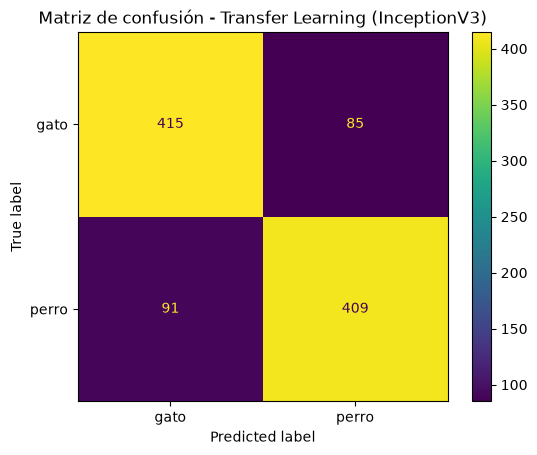

In [24]:
ConfusionMatrixDisplay.from_predictions(y_test, predicciones,
                                         display_labels=["gato", "perro"])
plt.title("Matriz de confusión - Transfer Learning (InceptionV3)")
plt.show()

-- Liberamos memoria antes del fine-tuning

In [29]:
del model
del history
gc.collect()

NameError: name 'model' is not defined

### **4. Fine-tuning**

4.1. Carga del modelo

In [30]:
base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(TAM, TAM, 3))

def prepare_model(base_model=base_model):
    x = keras.layers.Flatten()(base_model.output)
    x = keras.layers.Dense(512, activation='relu')(x)
    x = keras.layers.Dropout(rate=0.5)(x)
    x = keras.layers.Dense(1, activation='sigmoid')(x)

    model = keras.Model(base_model.input, x)
    # Learning rate mucho más bajo que el 0.001 por defecto de Adam
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

model = prepare_model()

Los 34K "non-trainable" son las medias/varianzas internas de BatchNormalization, que nunca se entrenan por gradiente, ni siquiera con trainable=True.

4.2. Entrenamiento del modelo

In [31]:
t_zero = time()
history = model.fit(X_train, y_train,
                    batch_size=32,
                    validation_split=0.2,
                    epochs=30,
                    callbacks=[early_stopping])
tiempo = round(time() - t_zero, 3)
print("Tiempo entrenamiento:", tiempo, "segundos")

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 48s 234ms/step - accuracy: 0.5016 - loss: 0.7354 - val_accuracy: 0.5487 - val_loss: 0.6910
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 212ms/step - accuracy: 0.5356 - loss: 0.7035 - val_accuracy: 0.5788 - val_loss: 0.6638
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 205ms/step - accuracy: 0.5578 - loss: 0.6895 - val_accuracy: 0.6562 - val_loss: 0.6547
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 20s 196ms/step - accuracy: 0.5981 - loss: 0.6609 - val_accuracy: 0.6625 - val_loss: 0.6784
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 220ms/step - accuracy: 0.6234 - loss: 0.6401 - val_accuracy: 0.6637 - val_loss: 0.6706
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 216ms/step - accuracy: 0.6500 - loss: 0.6258 - val_accuracy: 0.6900 - val_loss: 0.6382
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 22s 218ms/step - accuracy: 0.6862 - loss: 0.5977 - val_accuracy: 0.7000 - val_loss: 0.6192
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 21s 214ms/step - accuracy: 0.7009 - loss: 0

Primer intento de fine-tuning: descongelamos toda la InceptionV3 pero mantuvimos el learning_rate por defecto de Adam (0.001). El resultado fue val_loss disparada y oscilando sin control (5082, 17, 19, 4.6, 407...) en vez de bajar progresivamente. Esto es "catastrophic forgetting": con 22M de pesos ya ajustados por ImageNet, un learning rate pensado para entrenar una cabeza desde cero es demasiado agresivo y destruye ese conocimiento previo en vez de ajustarlo con suavidad. Solución: bajar el learning_rate a 1e-5 solo para el fine-tuning, para que los pesos preentrenados se muevan poco a poco en vez de a saltos.

Comprobación vs. test

In [32]:
loss_test, accuracy_test = model.evaluate(X_test, y_test)
print("Loss en test:", loss_test)
print("Accuracy en test:", accuracy_test)

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.7800 - loss: 0.4791
Loss en test: 0.4790973961353302
Accuracy en test: 0.7799999713897705


Classification report

In [33]:
probabilidades = model.predict(X_test).flatten()
predicciones = (probabilidades > 0.5).astype(int)

print(classification_report(y_test, predicciones, target_names=["gato", "perro"]))

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step
              precision    recall  f1-score   support

        gato       0.78      0.78      0.78       500
       perro       0.78      0.78      0.78       500

    accuracy                           0.78      1000
   macro avg       0.78      0.78      0.78      1000
weighted avg       0.78      0.78      0.78      1000



Matriz de confusión

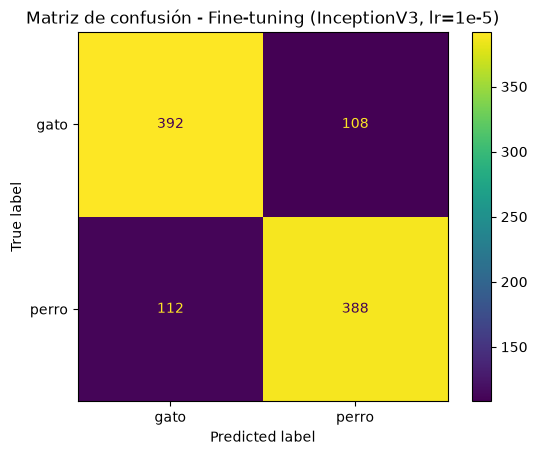

In [34]:
ConfusionMatrixDisplay.from_predictions(y_test, predicciones,
                                         display_labels=["gato", "perro"])
plt.title("Matriz de confusión - Fine-tuning (InceptionV3, lr=1e-5)")
plt.show()

El transfer learning con InceptionV3 (82.4%) supera claramente a la CNN ad-hoc tanto sin augmentation (71%, +11.4 p.p.) como con augmentation (77%, +5.4 p.p.), a pesar de entrenar solo ~1M de parámetros (la cabeza) frente a los 1.6M de la CNN ad-hoc entrenados desde cero. El fine-tuning (78.0%), sorprendentemente, no mejora sobre el transfer learning: con un dataset de solo 4000 imágenes, ajustar los 22.8M de parámetros de InceptionV3 no aporta ventaja sobre dejar el conocimiento de ImageNet congelado y entrenar únicamente la cabeza. Además requirió ~15 veces más tiempo de entrenamiento (523s vs 35s) para un resultado peor. Esto confirma que las features genéricas aprendidas por InceptionV3 en ImageNet (bordes, texturas, formas) ya eran suficientemente buenas para diferenciar gatos de perros, y que el margen de mejora estaba en la cabeza decisora, no en el extractor de características.

**EXTRA**

Volvemos a liberar memoria

In [36]:
del model
del history
gc.collect()

16229

In [37]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Sin rescale, porque X_train ya está en rango -1,1 (preprocesado para Inception)
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# Separación manual de validación (validation_split no funciona con generadores)
X_train2, y_train2 = X_train[:3200], y_train[:3200]
X_val, y_val = X_train[3200:], y_train[3200:]

In [38]:
base_model = InceptionV3(include_top=False, weights='imagenet', input_shape=(TAM, TAM, 3))
for layer in base_model.layers:
    layer.trainable = False

model = prepare_model(base_model)  # misma cabeza de siempre

history = model.fit(datagen.flow(X_train2, y_train2, batch_size=32),
                    epochs=30,
                    validation_data=(X_val, y_val),
                    callbacks=[early_stopping])

Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.5147 - loss: 1.0452 - val_accuracy: 0.5913 - val_loss: 0.7249
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - accuracy: 0.5484 - loss: 0.9428 - val_accuracy: 0.6450 - val_loss: 0.6368
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.5650 - loss: 0.8756 - val_accuracy: 0.6762 - val_loss: 0.6007
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.5903 - loss: 0.8110 - val_accuracy: 0.7013 - val_loss: 0.5653
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.6112 - loss: 0.7773 - val_accuracy: 0.7125 - val_loss: 0.5500
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 52ms/step - accuracy: 0.6263 - loss: 0.7517 - val_accuracy: 0.7212 - val_loss: 0.5370
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.6197 - loss: 0.7380 - val_accuracy: 0.7387 - val_loss: 0.5224
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 54ms/step - accuracy: 0.6541 - loss: 0.7043 - val_acc

In [39]:
loss_test, accuracy_test = model.evaluate(X_test, y_test)
print("Accuracy en test:", accuracy_test)

probabilidades = model.predict(X_test).flatten()
predicciones = (probabilidades > 0.5).astype(int)
print(classification_report(y_test, predicciones, target_names=["gato", "perro"]))

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - accuracy: 0.8000 - loss: 0.4297
Accuracy en test: 0.800000011920929
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 111ms/step
              precision    recall  f1-score   support

        gato       0.80      0.80      0.80       500
       perro       0.80      0.80      0.80       500

    accuracy                           0.80      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.80      0.80      0.80      1000



El extra (transfer learning + augmentation) alcanza 80.0% en test, mejorando la CNN ad-hoc (71%/77%) y el fine-tuning (78.0%), pero sin llegar al transfer learning sin augmentation (82.4%). El augmentation ayuda a que el modelo generalice sobre variaciones de las imágenes, pero con un dataset ya de por sí pequeño (4000 imágenes), la reducción efectiva de datos por batch y el ruido añadido por las transformaciones no compensan en este caso frente a entrenar directamente sobre las imágenes reales.

En conjunto, mejor resultado de toda la práctica --> transfer learning simple con InceptionV3 (82.4%), superando a la CNN ad-hoc de la práctica anterior. Ni el fine-tuning ni el augmentation logran mejorarlo con este volumen de datos: parece que las features preentrenadas de ImageNet ya capturaban todo lo necesario para distinguir gatos de perros, y añadir más flexibilidad al modelo (fine-tuning) o más variabilidad a los datos (augmentation) solo introduce ruido sin aportar señal nueva.

In [ ]:
:)